# CNN-LSTM Benchmark (Google Colab)

Deep learning benchmark to test whether tabular transaction data has
spatial/sequential structure that Conv1D and LSTM layers can exploit.
Each transaction is treated as an independent feature vector rather than
a true per-user sequence -- average UID history is only 2.2 transactions
(Notebook 03), too short for genuine sequence modelling.

Run with GPU runtime enabled. Upload `train_engineered.parquet` before running.

In [1]:
# Colab Setup

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install tensorflow -q
    TRAIN_PATH = 'split_train_engineered.parquet'
    TEST_PATH  = 'split_test_engineered.parquet'
else:
    TRAIN_PATH = '../data/split_train_engineered.parquet'
    TEST_PATH  = '../data/split_test_engineered.parquet'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
import joblib

warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

split_train = pd.read_parquet(TRAIN_PATH)
split_test  = pd.read_parquet(TEST_PATH)

print(f'split_train: {split_train.shape} | fraud rate: {split_train["isFraud"].mean():.2%}')
print(f'split_test:  {split_test.shape}  | fraud rate: {split_test["isFraud"].mean():.2%}')

TensorFlow version: 2.20.0
GPU available: True
split_train: (472432, 374) | fraud rate: 3.51%
split_test:  (118108, 374)  | fraud rate: 3.44%


In [2]:
# Feature/target definition. Split already happened in Notebook 01.

TARGET    = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS += split_train.select_dtypes('object').columns.tolist()
DROP_COLS  = [c for c in DROP_COLS if c in split_train.columns]
FEATURES   = [c for c in split_train.columns if c not in DROP_COLS]

X_train = split_train[FEATURES].fillna(0).values
y_train = split_train[TARGET].values
X_test  = split_test[FEATURES].fillna(0).values
y_test  = split_test[TARGET].values

# Scale features (neural networks require normalized input).
# fit on X_train only, transform both -- same principle as everywhere else
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Reshape for CNN-LSTM: (samples, timesteps, features)
# Each feature is treated as a pseudo-timestep -- see report Section 4.3
# for the limitation this implies (no true per-user transaction sequence)
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f'X_train shape: {X_train_3d.shape}')
print(f'X_test shape:  {X_test_3d.shape}')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weight for fraud: {class_weight[1]:.1f}')

X_train shape: (472432, 340, 1)
X_test shape:  (118108, 340, 1)
Class weight for fraud: 27.5


In [3]:
# ── CNN-LSTM Architecture ─────────────────────────────────────────────────────
#
# Architecture design:
# - Conv1D: extract local feature interactions (spatial patterns)
# - LSTM:   capture sequential dependencies (temporal patterns)
# - Dense:  final classification
#
# Reference: "Hybrid CNN-LSTM with Attention for Credit Card Fraud" (IEEE Access, 2025)

def build_cnn_lstm(input_shape, dropout_rate=0.3):
    inputs = keras.Input(shape=input_shape)

    # CNN block: spatial feature extraction
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # LSTM block: temporal sequence modelling
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Classification head
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_cnn_lstm(input_shape=(X_train_3d.shape[1], 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 340, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 340, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 340, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 340, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 170, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 170, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 170, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,025 (175.88 KB)

 Trainable params: 44,897 (175.38 KB)

 Non-trainable params: 128 (512.00 B)

In [4]:
# Training

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'),
             keras.metrics.AUC(curve='PR', name='auc_pr')]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=3, mode='max'
    )
]

print('Training CNN-LSTM...')
history = model.fit(
    X_train_3d, y_train,
    validation_data=(X_test_3d, y_test),
    epochs=30,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Training CNN-LSTM...
Epoch 1/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 53s 154ms/step - auc: 0.7786 - auc_pr: 0.1650 - loss: 1.0857 - val_auc: 0.7826 - val_auc_pr: 0.1767 - val_loss: 0.6743 - learning_rate: 0.0010
Epoch 2/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 35s 150ms/step - auc: 0.8113 - auc_pr: 0.2172 - loss: 1.0209 - val_auc: 0.7941 - val_auc_pr: 0.2517 - val_loss: 0.7839 - learning_rate: 0.0010
Epoch 3/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 36s 154ms/step - auc: 0.8246 - auc_pr: 0.2577 - loss: 0.9890 - val_auc: 0.8116 - val_auc_pr: 0.2971 - val_loss: 0.5129 - learning_rate: 0.0010
Epoch 4/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 37s 159ms/step - auc: 0.8331 - auc_pr: 0.2936 - loss: 0.9656 - val_auc: 0.8115 - val_auc_pr: 0.2938 - val_loss: 0.5404 - learning_rate: 0.0010
Epoch 5/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 36s 158ms/step - auc: 0.8380 - auc_pr: 0.3137 - loss: 0.9523 - val_auc: 0.8164 - val_auc_pr: 0.3304 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 6/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 36s 158ms/step - auc: 0.

58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step

=== CNN-LSTM RESULTS ===
AUC-ROC:   0.8383
AUC-PR:    0.3792
F1:        0.1921

-> Copy these numbers into Notebook 04 results table


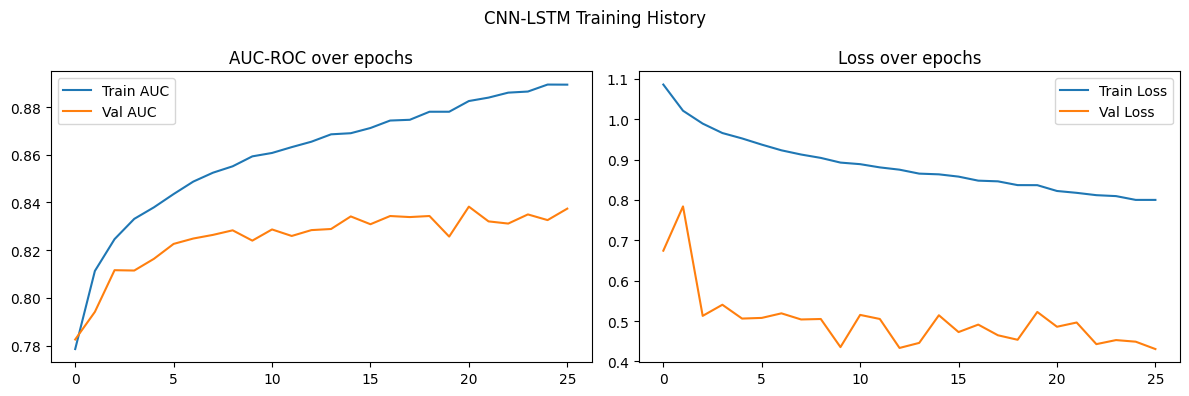

Saved: cnn_lstm_training.png
Download this file and add to reports/ folder in your repository


In [5]:
# Evaluation

cnn_proba = model.predict(X_test_3d, batch_size=2048).flatten()
cnn_pred  = (cnn_proba >= 0.5).astype(int)

auc_roc = roc_auc_score(y_test, cnn_proba)
auc_pr  = average_precision_score(y_test, cnn_proba)
f1      = f1_score(y_test, cnn_pred)

print('\n=== CNN-LSTM RESULTS ===')
print(f'AUC-ROC:   {auc_roc:.4f}')
print(f'AUC-PR:    {auc_pr:.4f}')
print(f'F1:        {f1:.4f}')
print('\n-> Copy these numbers into Notebook 04 results table')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['auc'], label='Train AUC')
axes[0].plot(history.history['val_auc'], label='Val AUC')
axes[0].set_title('AUC-ROC over epochs')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over epochs')
axes[1].legend()

plt.suptitle('CNN-LSTM Training History')
plt.tight_layout()
plt.savefig('cnn_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_lstm_training.png')
print('Download this file and add to reports/ folder in your repository')

In [6]:
# Inference time benchmark

# Single transaction inference on CPU
single_input = X_test_3d[:1]

times = []
for _ in range(100):
    start = time.time()
    _ = model.predict(single_input, verbose=0)
    times.append((time.time() - start) * 1000)

avg_ms = np.mean(times)
print(f'Average inference time (single transaction): {avg_ms:.1f}ms')
print(f'Meets <300ms requirement: {"YES" if avg_ms < 300 else "NO"}')
print('\nNote: This is measured on Colab GPU/CPU. Real deployment on CPU will be slower.')

Average inference time (single transaction): 77.1ms
Meets <300ms requirement: YES

Note: This is measured on Colab GPU/CPU. Real deployment on CPU will be slower.


## Cost-Sensitive Threshold Optimization

Same protocol as Notebook 04, applied to CNN-LSTM's predictions.


In [7]:
COST_FP = 10
test_amounts = split_test['TransactionAmt'].values

thresholds  = np.arange(0.05, 0.95, 0.01)
total_costs = []
f1_scores_sweep = []

for thresh in thresholds:
    preds = (cnn_proba >= thresh).astype(int)

    fn_mask = (preds == 0) & (y_test == 1)
    fn_cost = test_amounts[fn_mask].sum()

    fp_mask = (preds == 1) & (y_test == 0)
    fp_cost = fp_mask.sum() * COST_FP

    total_costs.append(fn_cost + fp_cost)
    f1_scores_sweep.append(f1_score(y_test, preds))

total_costs = np.array(total_costs)
optimal_idx    = np.argmin(total_costs)
optimal_thresh = thresholds[optimal_idx]
optimal_cost   = total_costs[optimal_idx]

no_model_cost = test_amounts[y_test == 1].sum()
savings     = no_model_cost - optimal_cost
savings_pct = savings / no_model_cost * 100

print('=== CNN-LSTM Cost-Sensitive Threshold Optimization ===')
print(f'Optimal threshold:     {optimal_thresh:.2f}')
print(f'Total cost at optimal: ${optimal_cost:,.0f}')
print(f'No-model cost:         ${no_model_cost:,.0f}')
print(f'Savings:               ${savings:,.0f} ({savings_pct:.1f}%)')
print(f'\n-> Compare against Notebook 04 winner: LightGBM $327,398 (53.7%)')

=== CNN-LSTM Cost-Sensitive Threshold Optimization ===
Optimal threshold:     0.73
Total cost at optimal: $449,325
No-model cost:         $609,934
Savings:               $160,609 (26.3%)

-> Compare against Notebook 04 winner: LightGBM $327,398 (53.7%)


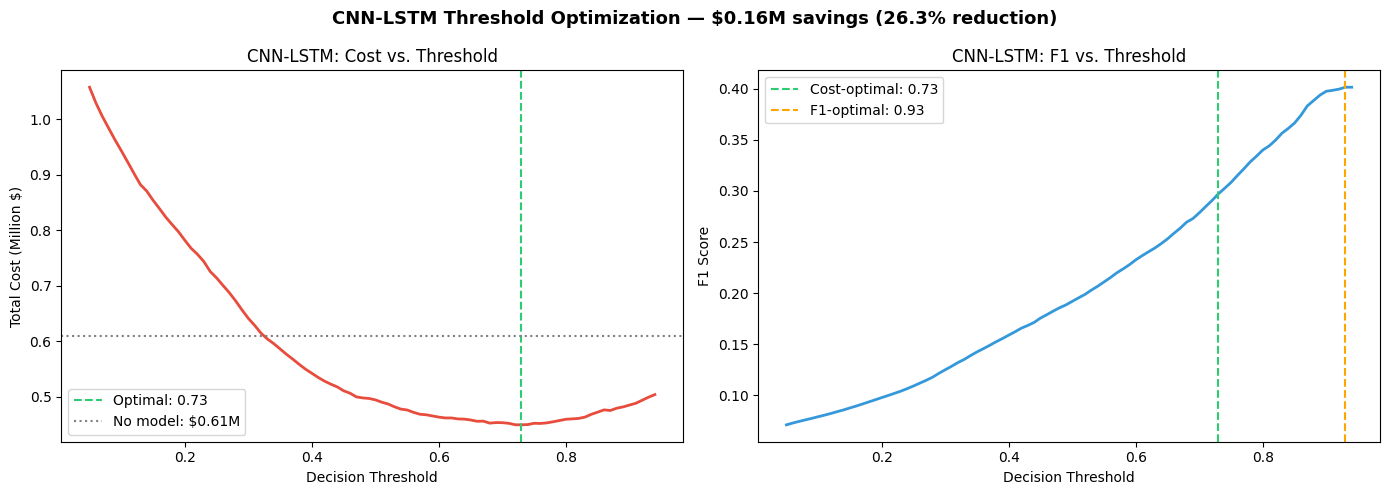

Saved: cnn_lstm_threshold_optimization.png
Download this file and add it to reports/ in your repository


In [8]:
# Plot: Cost vs Threshold (CNN-LSTM)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, total_costs / 1e6, color='#e74c3c', linewidth=2)
axes[0].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Optimal: {optimal_thresh:.2f}')
axes[0].axhline(no_model_cost / 1e6, color='gray', linestyle=':',
                label=f'No model: ${no_model_cost/1e6:.2f}M')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (Million $)')
axes[0].set_title('CNN-LSTM: Cost vs. Threshold')
axes[0].legend()

axes[1].plot(thresholds, f1_scores_sweep, color='#3498db', linewidth=2)
axes[1].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Cost-optimal: {optimal_thresh:.2f}')
f1_optimal_idx = np.argmax(f1_scores_sweep)
axes[1].axvline(thresholds[f1_optimal_idx], color='orange', linestyle='--',
                label=f'F1-optimal: {thresholds[f1_optimal_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('CNN-LSTM: F1 vs. Threshold')
axes[1].legend()

plt.suptitle(f'CNN-LSTM Threshold Optimization — ${savings/1e6:.2f}M savings ({savings_pct:.1f}% reduction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_lstm_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_lstm_threshold_optimization.png')
print('Download this file and add it to reports/ in your repository')

In [9]:
# Save predictions so we don't lose them if the Colab runtime disconnects

joblib.dump(cnn_proba, 'cnn_proba.pkl')
joblib.dump(y_test, 'y_test_cnn.pkl')
joblib.dump(test_amounts, 'test_amounts_cnn.pkl')
joblib.dump({
    'optimal_threshold': optimal_thresh,
    'optimal_cost': optimal_cost,
    'no_model_cost': no_model_cost,
    'savings': savings,
    'savings_pct': savings_pct
}, 'cnn_lstm_cost_results.pkl')

print('Saved: cnn_proba.pkl, y_test_cnn.pkl, test_amounts_cnn.pkl, cnn_lstm_cost_results.pkl')
print('Download these now via the Colab file browser (left sidebar) before the session ends.')

Saved: cnn_proba.pkl, y_test_cnn.pkl, test_amounts_cnn.pkl, cnn_lstm_cost_results.pkl
Download these now via the Colab file browser (left sidebar) before the session ends.


In [10]:
# Save the actual Keras model for local inference benchmarking

model.save('cnn_lstm_model.keras')
print('Saved: cnn_lstm_model.keras')
print('Download this file now via the Colab file browser (left sidebar) before the session ends.')

Saved: cnn_lstm_model.keras
Download this file now via the Colab file browser (left sidebar) before the session ends.
